# Semantic segmentation project

## Importing Libraries

In [1]:
import tensorflow as tf
import numpy as np
import glob
import matplotlib.image as mpimg
import matplotlib.pyplot as plt
import cv2
from sklearn.utils import shuffle

2026-04-05 20:46:06.575056: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775418366.765957     572 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775418366.813938     572 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1775418367.306395     572 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775418367.306426     572 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775418367.306429     572 computation_placer.cc:177] computation placer alr

## Loading Data

In [2]:
parent = "./data"

train_images_dir = "/training/image_2/*.png"
train_masks_dir = "/training/gt_image_2/*road*.png"

test_images_dir = "/testing/image_2/*.png"
#test_masks_dir = "./testing/gt_image_2/*"

In [2]:
def get_images_list(path):
    images_list = glob.glob(parent+path)
    return images_list

In [3]:
def load_data(train=0):
    if train:
        images_list = get_images_list(train_images_dir)
        masks_list = get_images_list(train_masks_dir)
        return images_list, masks_list
    else:
        images_list = get_images_list(test_images_dir)
        #masks_list = get_images_list(test_masks_dir)
        return images_list

def load_images(path_list):
    images = []
    for path in path_list:
        image = cv2.resize(cv2.imread(path), (224, 224))
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        images.append(image)
    return np.stack(images, dtype=np.uint8)

In [5]:
train_images_path_list, train_masks_path_list = load_data(train=1)
train_images_path_list, train_masks_path_list = shuffle(train_images_path_list, train_masks_path_list, random_state=42)
test_images_path_list = load_data()

In [6]:
print("Total train images = " + str(len(train_images_path_list)))
print("Total train masks = " + str(len(train_masks_path_list)))
print("Total test images = " + str(len(test_images_path_list)))

Total train images = 289
Total train masks = 289
Total test images = 290


In [7]:
unp_train_images = load_images(train_images_path_list)
unp_test_images = load_images(test_images_path_list)
unp_train_masks = load_images(train_masks_path_list)

In [8]:
#unp_train_images, unp_train_masks = shuffle(unp_train_images, unp_train_masks, random_state=42)

## Data preprocessing

In [4]:
def preprocess_image(images):
    im_list = []
    images = images.astype(np.float32)
    new_im = (images-128)/128
    return np.stack(new_im)

def preprocess_masks(masks):
    mask_list = []
    for mask in masks:
        mask_list.append(mask/255)
    return np.array(mask_list, dtype=np.uint8)

In [10]:
## Preprocess Pipeline
# 1. Load images
# 2. Normalize the data
train_images = preprocess_image(unp_train_images)

train_masks = preprocess_masks(unp_train_masks)#/255, dtype=np.uint8)


test_images = preprocess_image(unp_test_images)

In [11]:
print(f"Shape of train images {train_images.shape}")
print(f"Shape of train masks {train_masks.shape}")
print(f"Shape of test images {test_images.shape}")

Shape of train images (289, 224, 224, 3)
Shape of train masks (289, 224, 224, 3)
Shape of test images (290, 224, 224, 3)


## Model definition

In [5]:
from tensorflow.keras.applications import ResNet50, VGG16
from keras.layers import UpSampling2D, Conv2D, Concatenate, Conv2DTranspose, BatchNormalization, Activation, MaxPooling2D, Add
from keras.models import Model
from tensorflow.keras.callbacks import *
from tensorflow.keras.regularizers import l2

In [6]:
def pretrained_cnn_model(input_shape, trainable=False):
    backbone = ResNet50(
        weights="imagenet",
        include_top=False,
        input_shape=input_shape
    )
    backbone.trainable=trainable
    return backbone

def pretrained_vgg16(input_shape, trainable=False):
    backbone = VGG16(
        weights="imagenet",
        include_top=False,
        input_shape=input_shape
    )
    backbone.trainable=trainable
    return backbone

In [7]:
def conv_block(x, depth, encoder=0):
    x = Conv2D(depth, 3, padding="same", kernel_regularizer=l2(1e-4))(x)
    x = BatchNormalization()(x)
    x = Activation("relu")(x)
    x = Conv2D(depth, 3, padding="same", kernel_regularizer=l2(1e-4))(x)
    x = BatchNormalization()(x)
    x = Activation("relu")(x)
    if encoder:
        x = MaxPooling2D()(x)
    return x

In [8]:
def encoder(input_shape, base_model):
    layer_names = [
        "conv1_relu",
        "conv2_block3_out",
        "conv3_block4_out",
        "conv4_block6_out",
        "conv5_block3_out"
    ]
    layers = [base_model.get_layer(name).output for name in layer_names]
    model = Model(base_model.input, layers)
    return model

def encoder_fcn(input_shape, base_model):
    layer_names = [
        "block3_pool",
        "block4_pool",
        "block5_pool"
    ]
    layers = [base_model.get_layer(name).output for name in layer_names]
    model = Model(base_model.input, layers)
    return model

def additional_encoder(x, num_classes, encode):
    x = Conv2D(4096, 7, padding="same", activation="relu", kernel_regularizer=l2(1e-4))(x)
    x = Conv2D(4096, 1, padding="same", activation="relu", kernel_regularizer=l2(1e-4))(x)
    x = Conv2D(num_classes, 1, padding="same", activation="relu")(x)
    print(x.shape)
    return x

In [9]:
def transpose_block(x, filters, conc=[], skip=1):
    x = UpSampling2D()(x)
    if skip:
        x = Concatenate()([x, conc])
    output = conv_block(x, filters)
    return output

def transpose_block_fcn(x, num_classes, stride, kernel, conc=[], skip=1):
    x = Conv2DTranspose(num_classes, kernel, stride, padding="same")(x)
    conc = Conv2D(num_classes, 1, padding="same")(x)
    output = Add()([x, conc])
    return output

In [10]:
def decoder(inp, skip):
    x = transpose_block(inp, 512, skip[-1])
    x = transpose_block(x, 256, skip[2])
    x = transpose_block(x, 128, skip[1])
    output = transpose_block(x, 64, skip[0])
    return output

def decoder_fcn(inp, skip, num_classes):
    x = transpose_block_fcn(inp, num_classes, 2, 4, skip[-1])
    output = transpose_block_fcn(x, num_classes, 2, 4, skip[0])
    #output = transpose_block(x, 64, skip=0)
    return output

In [11]:
def seg_model(input_shape=(224, 224, 3), num_classes=3):
    base_model = pretrained_cnn_model(input_shape, trainable=False)
    encoder_out = encoder(input_shape, base_model)
    c1, c2, c3, c4, c5 = encoder_out.output
    decoder_out = decoder(c5, [c1, c2, c3, c4])
    x = Conv2DTranspose(32, 2, 2, padding="same")(decoder_out)
    output = Conv2D(num_classes, 1, activation="sigmoid")(x)
    model = Model(inputs=base_model.input, outputs=output)
    return model

def fcn8_model(input_shape=(224, 224, 3), num_classes=3):
    base_model = pretrained_vgg16(input_shape, trainable=False)
    encoder_out = encoder_fcn(input_shape, base_model)
    num_classes=3
    c1, c2, c3 = encoder_out.output
    c3 = additional_encoder(c3, num_classes, 1)
    decoder_out = decoder_fcn(c3, [c1, c2], num_classes)
    output = Conv2DTranspose(num_classes, 16, 8, padding="same")(decoder_out)
    model = Model(inputs=base_model.input, outputs=output)
    return model

## Model training

In [12]:
batch_size=4
learning_rate=1e-4
epochs = 50#60

In [14]:
def dice_loss(y_true, y_pred, smooth=1e-6):
    #y_true = tf.cast(y_true, tf.float32)
    #y_pred = tf.cast(y_pred, tf.float32)

    intersection = tf.reduce_sum(y_true * y_pred, axis=[1, 2, 3])
    union = tf.reduce_sum(y_true, axis=[1, 2, 3]) + tf.reduce_sum(y_pred, axis=[1, 2, 3])
    dice = (2.0 * intersection + smooth) / (union + smooth)
    return 1.0 - tf.reduce_mean(dice)

bce = tf.keras.losses.BinaryCrossentropy()

def bce_dice_loss(y_true, y_pred):
    return bce(y_true, y_pred) + dice_loss(y_true, y_pred)

In [15]:
#model = fcn8_model()
model = seg_model()
#model = Model(backbone.input, output)
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
    loss = dice_loss,
    metrics = ["accuracy"]
)

I0000 00:00:1775418390.234300     572 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 6096 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 2070 with Max-Q Design, pci bus id: 0000:01:00.0, compute capability: 7.5


In [22]:
callbacks = [
    ReduceLROnPlateau(
        monitor='loss',
        factor=0.3,
        patience=5,
        min_lr=1e-6
    ),

    EarlyStopping(
        monitor='loss',
        patience=10,
        restore_best_weights=True
    ),

    ModelCheckpoint(
        "best_model.keras",
        save_best_only=True
    )
]

In [23]:
model.fit(
    train_images,
    train_masks,
    batch_size=batch_size,
    epochs=epochs,
    #callbacks=callbacks
)

Epoch 1/50


I0000 00:00:1775081929.386496  142570 service.cc:152] XLA service 0x73e47c003720 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1775081929.386585  142570 service.cc:160]   StreamExecutor device (0): NVIDIA GeForce RTX 2070 with Max-Q Design, Compute Capability 7.5
2026-04-01 23:18:49.787385: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1775081931.856185  142570 cuda_dnn.cc:529] Loaded cuDNN version 90300
2026-04-01 23:18:52.802715: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:549] Omitted potentially buggy algorithm eng14{k25=0} for conv %cudnn-conv-bias-activation.189 = (f32[4,64,56,56]{3,2,1,0}, u8[0]{0}) custom-call(f32[4,64,56,56]{3,2,1,0} %bitcast.12298, f32[64,64,3,3]{3,2,1,0} %bitcast.12305, f32[64]{0} %bitcast.12307), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, 

72/73 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step - accuracy: 0.6487 - loss: 0.7344

2026-04-01 23:19:17.745887: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:549] Omitted potentially buggy algorithm eng14{k25=0} for conv %cudnn-conv-bias-activation.199 = (f32[1,128,28,28]{3,2,1,0}, u8[0]{0}) custom-call(f32[1,128,28,28]{3,2,1,0} %bitcast.12805, f32[128,128,3,3]{3,2,1,0} %bitcast.12812, f32[128]{0} %bitcast.12814), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", metadata={op_type="Conv2D" op_name="functional_1_1/conv3_block1_2_conv_1/convolution" source_file="/home/forby/miniconda3/envs/sdc/lib/python3.11/site-packages/tensorflow/python/framework/ops.py" source_line=1200}, backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"conv_result_scale":1,"activation_mode":"kNone","side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false}
2026-04-01 23:19:18.026368: I external/local_xla/xla/service/gpu/autotuning/conv_algor

73/73 ━━━━━━━━━━━━━━━━━━━━ 48s 281ms/step - accuracy: 0.7522 - loss: 0.6613
Epoch 2/50
73/73 ━━━━━━━━━━━━━━━━━━━━ 8s 114ms/step - accuracy: 0.9372 - loss: 0.4260
Epoch 3/50
73/73 ━━━━━━━━━━━━━━━━━━━━ 8s 114ms/step - accuracy: 0.9933 - loss: 0.2671
Epoch 4/50
73/73 ━━━━━━━━━━━━━━━━━━━━ 8s 114ms/step - accuracy: 1.0000 - loss: 0.1858
Epoch 5/50
73/73 ━━━━━━━━━━━━━━━━━━━━ 8s 114ms/step - accuracy: 0.9999 - loss: 0.1447
Epoch 6/50
73/73 ━━━━━━━━━━━━━━━━━━━━ 8s 114ms/step - accuracy: 1.0000 - loss: 0.1195
Epoch 7/50
73/73 ━━━━━━━━━━━━━━━━━━━━ 8s 114ms/step - accuracy: 1.0000 - loss: 0.1034
Epoch 8/50
73/73 ━━━━━━━━━━━━━━━━━━━━ 8s 114ms/step - accuracy: 0.9998 - loss: 0.0905
Epoch 9/50
73/73 ━━━━━━━━━━━━━━━━━━━━ 8s 114ms/step - accuracy: 0.9990 - loss: 0.0814
Epoch 10/50
73/73 ━━━━━━━━━━━━━━━━━━━━ 8s 114ms/step - accuracy: 0.9980 - loss: 0.0734
Epoch 11/50
73/73 ━━━━━━━━━━━━━━━━━━━━ 8s 114ms/step - accuracy: 0.9991 - loss: 0.0674
Epoch 12/50
73/73 ━━━━━━━━━━━━━━━━━━━━ 8s 114ms/step - accurac

In [36]:
#model.save("model.keras")
model.save_weights("u_net.weights.h5")
#model.save_weights("fcn8.weights.h5")

## Finetuning model

In [37]:
results = model.predict(test_images)

10/10 ━━━━━━━━━━━━━━━━━━━━ 11s 664ms/step


In [38]:
p = 20

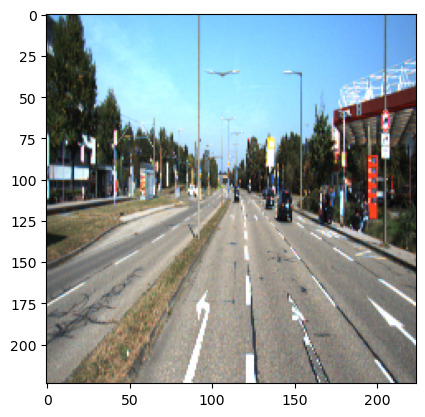

In [39]:
plt.imshow(unp_test_images[p])

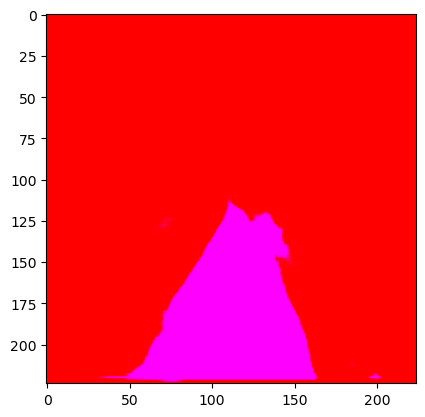

In [40]:
plt.imshow(results[p])

In [16]:
def save_image(image, mask, alpha=0.3):
    if hasattr(mask, "numpy"):
        mask = mask.numpy()
    if hasattr(image, "numpy"):
        image = image.numpy()
    masked_mask = (mask >= 0.9).astype(np.uint8)
    mask_only = (masked_mask[..., 0] == 1) & (masked_mask[..., 2] == 1)
    mask_only = mask_only.astype(np.uint8) * 255
    mask_rgb = np.zeros_like(image)
    mask_rgb[mask_only == 255] = [0, 255, 0]
    overlay = cv2.addWeighted(image, 1 - alpha, mask_rgb, alpha, 0)

    return overlay

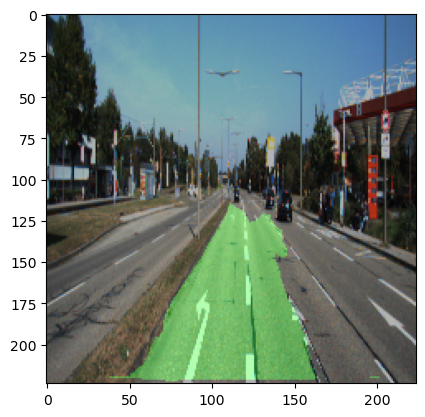

In [42]:
for i, (image, mask) in enumerate(zip(unp_test_images, results)):
    n_im = save_image(image, mask)
    if i == p:
        plt.imshow(n_im)
    cv2.imwrite(f"./data/processed_data/im{i}.png", n_im)

In [17]:
def seg_model(input_shape=(224, 224, 3), num_classes=3):
    base_model = pretrained_cnn_model(input_shape, trainable=True)
    encoder_out = encoder(input_shape, base_model)
    c1, c2, c3, c4, c5 = encoder_out.output
    decoder_out = decoder(c5, [c1, c2, c3, c4])
    x = Conv2DTranspose(32, 2, 2, padding="same")(decoder_out)
    output = Conv2D(num_classes, 1, activation="softmax")(x)
    model = Model(inputs=base_model.input, outputs=output)
    return model

def fcn8_model(input_shape=(224, 224, 3), num_classes=3):
    base_model = pretrained_vgg16(input_shape, trainable=True)
    encoder_out = encoder_fcn(input_shape, base_model)
    num_classes=3
    c1, c2, c3 = encoder_out.output
    c3 = additional_encoder(c3, num_classes, 1)
    decoder_out = decoder_fcn(c3, [c1, c2], num_classes)
    output = Conv2DTranspose(num_classes, 16, 8, padding="same")(decoder_out)
    print(output.shape)
    model = Model(inputs=base_model.input, outputs=output)
    return model

In [32]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss = dice_loss,
    metrics = ["accuracy"]
)

In [33]:
model.fit(
    train_images,
    train_masks,
    batch_size=batch_size,
    epochs=50,
)

Epoch 1/50
73/73 ━━━━━━━━━━━━━━━━━━━━ 34s 209ms/step - accuracy: 0.9626 - loss: 0.0176
Epoch 2/50
73/73 ━━━━━━━━━━━━━━━━━━━━ 8s 115ms/step - accuracy: 0.9720 - loss: 0.0170
Epoch 3/50
73/73 ━━━━━━━━━━━━━━━━━━━━ 8s 115ms/step - accuracy: 0.9722 - loss: 0.0168
Epoch 4/50
73/73 ━━━━━━━━━━━━━━━━━━━━ 8s 115ms/step - accuracy: 0.9763 - loss: 0.0166
Epoch 5/50
73/73 ━━━━━━━━━━━━━━━━━━━━ 8s 115ms/step - accuracy: 0.9763 - loss: 0.0163
Epoch 6/50
73/73 ━━━━━━━━━━━━━━━━━━━━ 8s 115ms/step - accuracy: 0.9777 - loss: 0.0161
Epoch 7/50
73/73 ━━━━━━━━━━━━━━━━━━━━ 8s 115ms/step - accuracy: 0.9787 - loss: 0.0159
Epoch 8/50
73/73 ━━━━━━━━━━━━━━━━━━━━ 8s 115ms/step - accuracy: 0.9781 - loss: 0.0158
Epoch 9/50
73/73 ━━━━━━━━━━━━━━━━━━━━ 8s 115ms/step - accuracy: 0.9797 - loss: 0.0157
Epoch 10/50
73/73 ━━━━━━━━━━━━━━━━━━━━ 8s 115ms/step - accuracy: 0.9802 - loss: 0.0155
Epoch 11/50
73/73 ━━━━━━━━━━━━━━━━━━━━ 8s 115ms/step - accuracy: 0.9807 - loss: 0.0154
Epoch 12/50
73/73 ━━━━━━━━━━━━━━━━━━━━ 8s 115ms/ste

## Evaluation and Metrics

## Performing inference

In [18]:
from keras.models import load_model
import time

In [ ]:
model = load_model("model.keras")

In [19]:
model.load_weights("u_net.weights.h5")

/home/forby/miniconda3/envs/sdc/lib/python3.11/site-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 74 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [20]:
def pipeline(image):
    original = image.shape
    resize_original = cv2.resize(image, (224, 224))
    image = preprocess_image(resize_original)
    image = image.reshape([-1, image.shape[0], image.shape[1], image.shape[2]])
    pred = model.predict(image)
    n_im = cv2.resize(save_image(resize_original, pred[0]), (original[1], original[0]))
    return n_im

In [21]:
import moviepy
from moviepy import VideoFileClip, ImageSequenceClip
import numpy as np
from tqdm import tqdm

class images_to_video():
    def __init__(self, images, video_path, fps):
        self.image_list = images
        self.video_path = video_path
        self.fps = fps


    def __call__(self):
        if self.image_list.dtype != np.uint8:
            if self.image_list.max() <= 1.0:
                self.image_list = (self.image_list * 255).astype(np.uint8)
            else:
                self.image_list = self.image_list.astype(np.uint8)
        clip = ImageSequenceClip(list(self.image_list), fps=self.fps)
        clip.write_videofile(self.video_path, codec="libx264", audio=False)
        print("Writing Video Completed")



class video_to_images():
    def __init__(self, video_path, fps=None):
        self.video_path = video_path
        self.fps = fps


    def __call__(self):
        clip = VideoFileClip(self.video_path)
        if self.fps:
            clip = clip.with_fps(self.fps)
        frames = clip.iter_frames()
        frames_list = list(frames)
        return np.array(frames_list)

In [22]:
fps=15
file_path = "./driving.mp4"
#file_path = "./challenge_video.mp4"
#file_path = "./harder_challenge_video.mp4"
images = video_to_images(file_path, fps)()

processed_images = []
fps_counter = []
tot_frames = 0
tot_start = time.time()
for image in images:
    start = time.time()
    tot_frames += 1
    processed_images.append(pipeline(image))
    end = time.time()
    diff = end - start
    fps = 1/diff
    fps_counter.append(fps)
tot_end = time.time()

avg_fps = tot_frames/(tot_end - tot_start)

I0000 00:00:1775418433.115326     799 service.cc:152] XLA service 0x7c3ab80156e0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1775418433.115380     799 service.cc:160]   StreamExecutor device (0): NVIDIA GeForce RTX 2070 with Max-Q Design, Compute Capability 7.5
2026-04-05 20:47:13.293573: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1775418434.827432     799 cuda_dnn.cc:529] Loaded cuDNN version 90300
2026-04-05 20:47:17.170095: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:549] Omitted potentially buggy algorithm eng14{k25=0} for conv %cudnn-conv-bias-activation.199 = (f32[1,128,28,28]{3,2,1,0}, u8[0]{0}) custom-call(f32[1,128,28,28]{3,2,1,0} %bitcast.5655, f32[128,128,3,3]{3,2,1,0} %bitcast.5662, f32[128]{0} %bitcast.5664), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01

1/1 ━━━━━━━━━━━━━━━━━━━━ 10s 10s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step


I0000 00:00:1775418440.560944     799 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━

In [24]:
print(f"The maximum fps is {max(fps_counter)} fps")
print(f"The minimum fps is {min(fps_counter)} fps")
print(f"The average fps is {avg_fps} fps")

The maximum fps is 12.273233765625731 fps
The minimum fps is 0.09744020551934827 fps
The average fps is 7.286169447743149 fps


In [25]:
save=images_to_video(np.array(processed_images), file_path+"_result.mp4", fps)()

MoviePy - Building video ./driving.mp4_result.mp4.
MoviePy - Writing video ./driving.mp4_result.mp4



MoviePy - Done !
MoviePy - video ready ./driving.mp4_result.mp4
Writing Video Completed


In [26]:
print(len(processed_images))

756


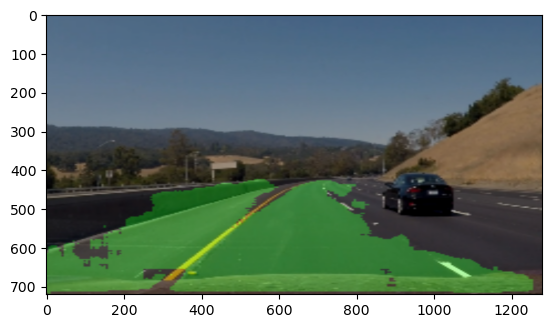

In [27]:
plt.imshow(processed_images[500])